# **THỰC HÀNH THỐNG KÊ MÔ TẢ VỀ COVID**

In [5]:
import numpy as np 
import pandas as pd 
from scipy import stats 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the .csv into a dataframe using read_csv 
covid_data = pd.read_csv("covid_data.csv") 


In [7]:
# so dong, so cot cua du lieu
print(f'Số dòng, số cột của dữ liệu: ', covid_data.shape)

Số dòng, số cột của dữ liệu:  (530292, 61)


### Hiển thị kiểu dữ liệu

In [8]:
# kieu du lieu cua tung cot
print(f'Kiểu dữ liệu của từng cột:\n',covid_data.dtypes)

Kiểu dữ liệu của từng cột:
 country                        object
date                           object
total_cases                   float64
new_cases                     float64
new_cases_smoothed            float64
                               ...   
extreme_poverty               float64
diabetes_prevalence           float64
handwashing_facilities        float64
hospital_beds_per_thousand    float64
human_development_index       float64
Length: 61, dtype: object


### Hiển thị 5 dòng đầu và 5 dòng cuối của dữ liệu

In [9]:
# hien thi 5 dong dau va 5 dong cuoi 
display(covid_data.head(5))
display(covid_data.tail(5))

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN


,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
530287,Zimbabwe,2025-09-03,266434.0,0.0,0.0,16580.559,0.0,0.0,5740.0,0.0,...,16069061.0,41.538223,17.683001,62.3601,2207.957031,49.219894,2.1,42.456093,1.7,NaN
530288,Zimbabwe,2025-09-04,266434.0,0.0,0.0,16580.559,0.0,0.0,5740.0,0.0,...,16069061.0,41.538223,17.683001,62.3601,2207.957031,49.219894,2.1,42.456093,1.7,NaN
530289,Zimbabwe,2025-09-05,266434.0,0.0,0.0,16580.559,0.0,0.0,5740.0,0.0,...,16069061.0,41.538223,17.683001,62.3601,2207.957031,49.219894,2.1,42.456093,1.7,NaN
530290,Zimbabwe,2025-09-06,266434.0,0.0,0.0,16580.559,0.0,0.0,5740.0,0.0,...,16069061.0,41.538223,17.683001,62.3601,2207.957031,49.219894,2.1,42.456093,1.7,NaN
530291,Zimbabwe,2025-09-07,266434.0,0.0,0.0,16580.559,0.0,0.0,5740.0,0.0,...,16069061.0,41.538223,17.683001,62.3601,2207.957031,49.219894,2.1,42.456093,1.7,NaN


### Hiển thị thông tin chung về dữ liệu

In [10]:
covid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530292 entries, 0 to 530291
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   country                                     530292 non-null  object 
 1   date                                        530292 non-null  object 
 2   total_cases                                 516426 non-null  float64
 3   new_cases                                   513144 non-null  float64
 4   new_cases_smoothed                          511939 non-null  float64
 5   total_cases_per_million                     516426 non-null  float64
 6   new_cases_per_million                       513144 non-null  float64
 7   new_cases_smoothed_per_million              511939 non-null  float64
 8   total_deaths                                516426 non-null  float64
 9   new_deaths                                  514015 non-null  float64
 

In [11]:
covid_copy = covid_data.copy() #tạo bản sao

### Kiểm tra tính toàn vẹn của dữ liệu

* Kiểm tra giá trị trùng lặp

In [13]:
# Kiểm tra dữ liệu trùng lặp
data_dup = covid_copy[covid_copy.duplicated(keep=False)]
if not data_dup.empty:
    print('So hang trung nhau: ', data_dup.shape[0])
    display.display(data_dup)
else:
    print('Khong co du lieu trung lap nao.')

Khong co du lieu trung lap nao.


* Kiểm tra giá trị null

In [14]:
# Kiểm tra giá trị thiếu
data_null = covid_copy[covid_copy.isnull().any(axis=1)]
if not data_null.empty:
    print(f'+ Null data: ', data_null.shape[0])
    display(data_null)
    print("Số lượng giá trị null theo từng cột:")
    print(covid_copy.isnull().sum())
else: print('No Null data.')


+ Null data:  50332


,code,continent,country,date,total_cases,new_cases
0,AFG,Asia,Afghanistan,2020-01-01,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-02,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-03,NaN,NaN
2077,OWID_AFR,NaN,Africa,2020-01-04,0.0,0.0
2078,OWID_AFR,NaN,Africa,2020-01-05,0.0,0.0
...,...,...,...,...,...,...
526140,ZMB,Africa,Zambia,2020-01-03,NaN,NaN
528215,ZWE,Africa,Zimbabwe,2020-01-01,NaN,NaN
528216,ZWE,Africa,Zimbabwe,2020-01-02,NaN,NaN
528217,ZWE,Africa,Zimbabwe,2020-01-03,NaN,NaN


Số lượng giá trị null theo từng cột:
code           23248
continent      39840
country            0
date               0
total_cases    13866
new_cases      17148
dtype: int64


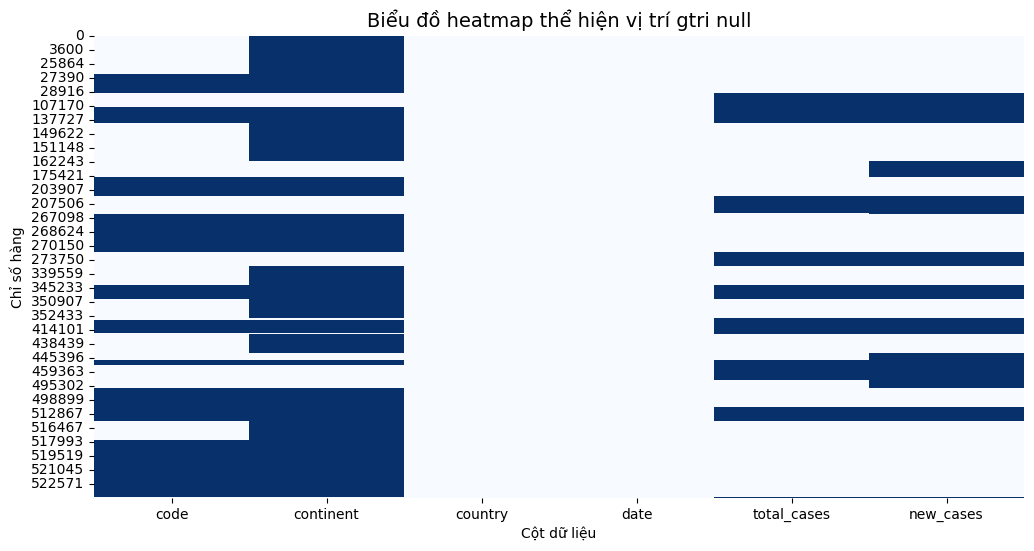

In [15]:
# Cach 2: Bieu do heatmap (ban do nhiet) de xem vi tri null
plt.figure(figsize=(12,6))
sns.heatmap(data_null.isnull(), cmap = 'Blues', cbar = False)

plt.title('Biểu đồ heatmap thể hiện vị trí gtri null', fontsize = 14)
plt.xlabel('Cột dữ liệu')
plt.ylabel('Chỉ số hàng')
plt.show()

* Giữ lại những đặc trưng cần thiết

In [18]:

covid_copy = covid_copy[['code','continent', 
'country','date','total_cases','new_cases']] 

### Hiển thị các tính chất thống kê trên dữ liệu số

In [20]:
description = covid_copy.describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
total_cases,516426.0,1.412012e+07,7.357503e+07,0.0,9106.0,84203.5,1067030.0,778523540.0
new_cases,513144.0,1.059008e+04,1.176220e+05,0.0,0.0,0.0,64.0,8401906.0


### Hiển thị dữ liệu trên từng tính chất đơn

* **Box and whisker plots**

<Axes: >

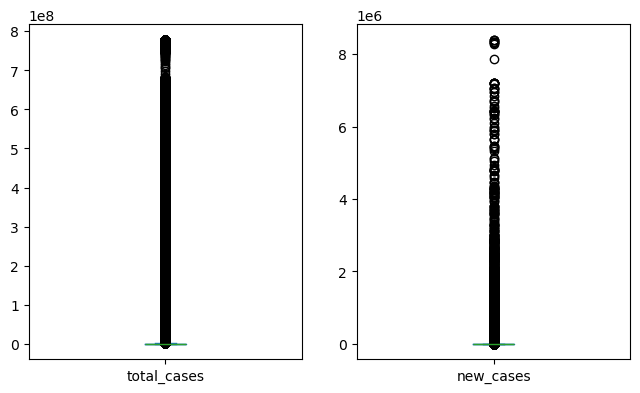

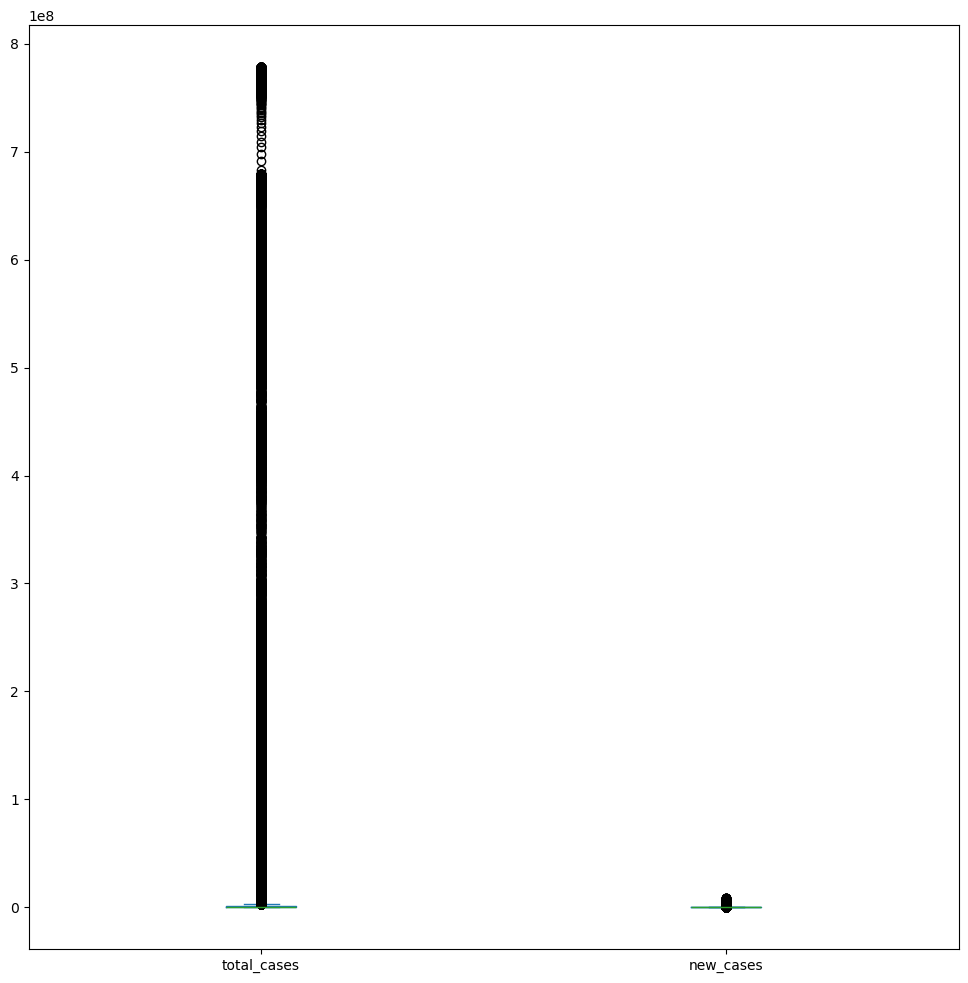

In [22]:
covid_copy.plot(kind="box", subplots=True, layout=(4, 3), sharex=False, sharey=False, figsize=(12, 20))
covid_copy.plot(kind="box", figsize=(12, 12))

* **Histogram**

array([[<Axes: title={'center': 'total_cases'}>,
        <Axes: title={'center': 'new_cases'}>]], dtype=object)

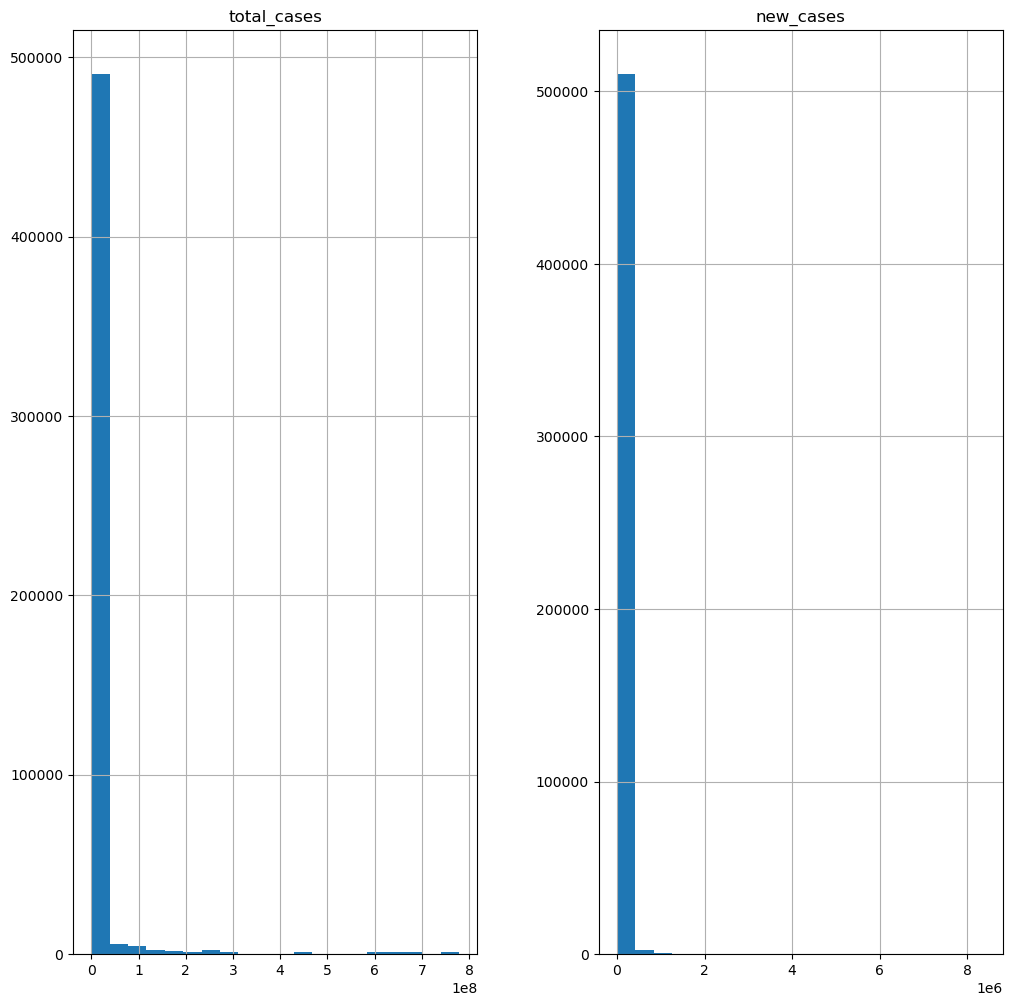

In [23]:
covid_copy.hist(figsize=(12, 12), bins= 20, sharex=False, sharey=False)

### Hiển thị nhiều tính chất của dữ liệu

array([[<Axes: xlabel='total_cases', ylabel='total_cases'>,
        <Axes: xlabel='new_cases', ylabel='total_cases'>],
       [<Axes: xlabel='total_cases', ylabel='new_cases'>,
        <Axes: xlabel='new_cases', ylabel='new_cases'>]], dtype=object)

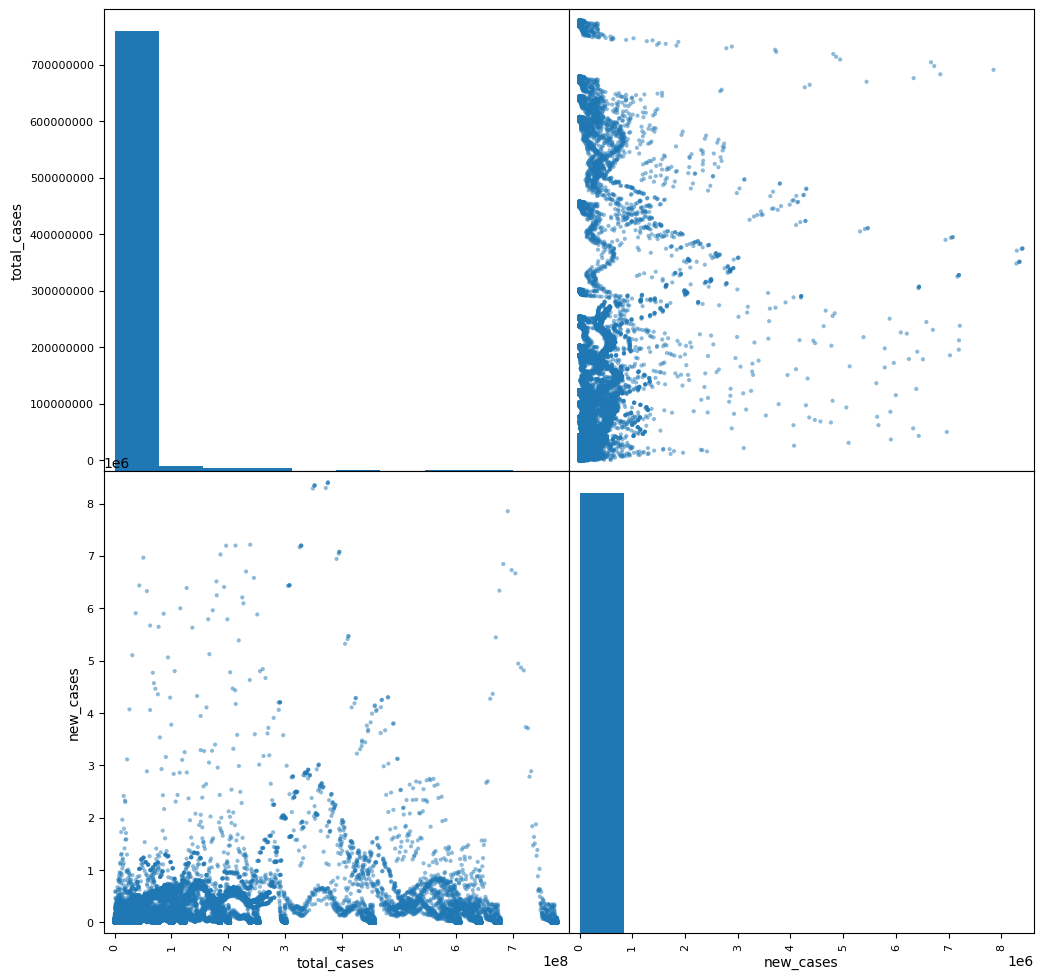

In [24]:
pd.plotting.scatter_matrix(covid_copy, figsize=(12, 12))

### Mối tương quan giữa các đặc trưng

In [28]:
covid_copy["new_cases"].corr(covid_copy["total_cases"])

np.float64(0.2548125804057803)